# Speech Emotion Recognition using RAVDESS Dataset
1. Introduction

This notebook presents a complete Speech Emotion Recognition (SER) pipeline using the RAVDESS Emotional Speech Audio dataset.
The goal is to classify human emotions from speech signals using hand-crafted audio features and a Multi-Layer Perceptron (MLP) classifier.

2. Libraries and Dependencies

In [1]:
import os
import glob
import numpy as np
import joblib
import librosa
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

3. Configuration and Hyperparameters

In [ ]:
DATA_DIR = r"C:\\Users\\user\\Desktop\\NTI ML & DATA ANALYSIS\\Final Project\\h\\DataSet"

SAMPLE_RATE = 16000
DURATION = 3.0
OFFSET = 0.0
N_MFCC = 40
N_MELS = 128
TEST_SIZE = 0.2
RANDOM_STATE = 42

OUT_MODEL = "ser_mlp.joblib"
OUT_LABELS = "label_encoder.joblib"

4. Emotion Label Mapping (RAVDESS)

In [3]:
RAVDESS_MAP = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "05": "angry",
    "08": "surprise",
}

def parse_label_from_filename(path):
    name = os.path.basename(path)
    parts = name.replace(".wav", "").split("-")
    return RAVDESS_MAP.get(parts[2], None) if len(parts) >= 3 else None

5. Audio Loading and Preprocessing

In [4]:
def load_audio(path, sr=SAMPLE_RATE, duration=DURATION, offset=OFFSET):
    y, _ = librosa.load(path, sr=sr, duration=duration, offset=offset)
    target_len = int(sr * duration)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    return y[:target_len]

6. Feature Extraction
The following features are extracted:

    Zero Crossing Rate (ZCR)

    Spectral Centroid

    MFCCs (mean & std)

    Chroma Features

    Mel Spectrogram (log scale)

In [5]:
def stats(x):
    return np.array([np.mean(x), np.std(x)], dtype=np.float32)

def extract_features(y, sr):
    zcr_feat = stats(librosa.feature.zero_crossing_rate(y)[0])
    sc_feat = stats(librosa.feature.spectral_centroid(y=y, sr=sr)[0])


    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
    mfcc_feat = np.hstack([np.mean(mfcc, axis=1), np.std(mfcc, axis=1)])


    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma_feat = np.hstack([np.mean(chroma, axis=1), np.std(chroma, axis=1)])
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_feat = np.hstack([np.mean(mel_db, axis=1), np.std(mel_db, axis=1)])


    return np.hstack([zcr_feat, sc_feat, mfcc_feat, chroma_feat, mel_feat]).astype(np.float32)

7. Dataset Construction

In [6]:
def build_dataset(data_dir):
    wavs = glob.glob(os.path.join(data_dir, "**", "*.wav"), recursive=True)
    X, y = [], []
    for p in wavs:
        label = parse_label_from_filename(p)
        if label:
            audio = load_audio(p)
            X.append(extract_features(audio, SAMPLE_RATE))
            y.append(label)
    return np.array(X), np.array(y)


X, y_text = build_dataset(DATA_DIR)

8. Label Encoding and Train/Test Split

In [7]:
le = LabelEncoder()
y = le.fit_transform(y_text)
joblib.dump(le, OUT_LABELS)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

9. Model Pipeline and Hyperparameter Tuning

In [8]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(max_iter=200, early_stopping=True, random_state=RANDOM_STATE))
])


param_grid = {
    "mlp__hidden_layer_sizes": [(256,), (512,), (256,128), (512,256)],
    "mlp__learning_rate_init": [1e-3, 5e-4],
    "mlp__alpha": [1e-4, 1e-3, 1e-2],
    "mlp__activation": ["relu", "tanh"],
}


gs = GridSearchCV(pipe, param_grid, scoring="accuracy", cv=3, n_jobs=-1, verbose=1)
gs.fit(X_train, y_train)


best_model = gs.best_estimator_

Fitting 3 folds for each of 48 candidates, totalling 144 fits


10. Model Evaluation

In [9]:
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)


train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)


print("Training Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print("\nClassification Report:\n", classification_report(y_test, y_test_pred, target_names=le.classes_))

Training Accuracy: 0.9978292329956585
Test Accuracy: 0.9566473988439307

Classification Report:
               precision    recall  f1-score   support

       angry       0.97      1.00      0.99        77
        calm       0.96      0.97      0.97        77
       happy       0.95      0.92      0.93        77
     neutral       0.94      0.87      0.90        38
    surprise       0.95      0.97      0.96        77

    accuracy                           0.96       346
   macro avg       0.96      0.95      0.95       346
weighted avg       0.96      0.96      0.96       346



11. Confusion Matrix Visualization

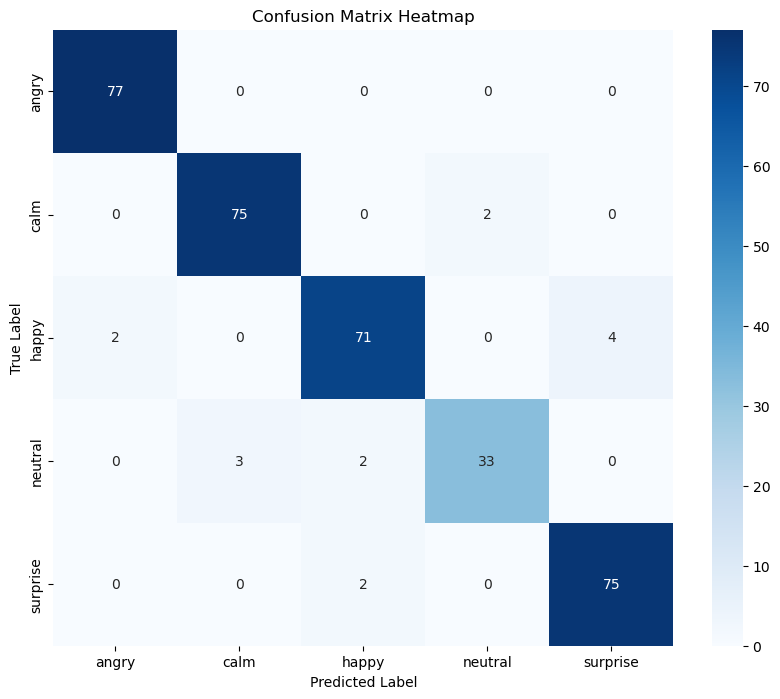

In [10]:
cm = confusion_matrix(y_test, y_test_pred)


plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

12. Saving the Model

In [11]:
joblib.dump(best_model, OUT_MODEL)
print("Model saved successfully")

Model saved successfully
